# 📌 Learning Rate Schedulers: Fixed, Step Decay, Exponential Decay, and Adaptive (Adam)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# ✅ Load the Housing Dataset

In [2]:
url = "https://raw.githubusercontent.com/Phionanamugga/teaching/refs/heads/main/datasets/housing.csv"
df = pd.read_csv(url)

# ✅ Prepare Features (X) and Target (y)

In [3]:
X = df.iloc[:, :-1].values  # Features (all columns except the last)
y = df.iloc[:, -1].values   # Target variable (last column)

# ✅ Split into Training & Test Sets

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ✅ Normalize Features (Gradient Descent is sensitive to scaling)

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# ✅ Add Bias Term (X0 = 1) for Intercept

In [6]:
X_train_b = np.c_[np.ones((X_train_scaled.shape[0], 1)), X_train_scaled]
X_test_b = np.c_[np.ones((X_test_scaled.shape[0], 1)), X_test_scaled]


# 🔹 1️⃣ FIXED LEARNING RATE 🔹

In [7]:
def sgd_fixed_lr(X, y, learning_rate=0.01, epochs=1000):
    m, n = X.shape
    theta = np.random.randn(n)  
    cost_history = []

    for epoch in range(epochs):
        gradients = 2 / m * X.T @ (X @ theta - y)
        theta -= learning_rate * gradients
        cost_history.append(mean_squared_error(y, X @ theta))

    return theta, cost_history


# 🔹 2️⃣ STEP DECAY 🔹

In [8]:
def sgd_step_decay(X, y, initial_lr=0.1, decay_rate=0.5, step_size=200, epochs=1000):
    m, n = X.shape
    theta = np.random.randn(n)  
    cost_history = []

    for epoch in range(epochs):
        learning_rate = initial_lr * (decay_rate ** (epoch // step_size))
        gradients = 2 / m * X.T @ (X @ theta - y)
        theta -= learning_rate * gradients
        cost_history.append(mean_squared_error(y, X @ theta))

    return theta, cost_history

# 🔹 3️⃣ EXPONENTIAL DECAY 🔹

In [9]:
def sgd_exponential_decay(X, y, initial_lr=0.1, decay_rate=0.01, epochs=1000):
    m, n = X.shape
    theta = np.random.randn(n)  
    cost_history = []

    for epoch in range(epochs):
        learning_rate = initial_lr * np.exp(-decay_rate * epoch)
        gradients = 2 / m * X.T @ (X @ theta - y)
        theta -= learning_rate * gradients
        cost_history.append(mean_squared_error(y, X @ theta))

    return theta, cost_history

# 🔹 4️⃣ ADAPTIVE LEARNING RATE (Adam) 🔹

In [10]:
def adam_gd(X, y, initial_lr=0.01, beta1=0.9, beta2=0.999, epsilon=1e-8, epochs=1000):
    m, n = X.shape
    theta = np.random.randn(n)  
    v, s = np.zeros(n), np.zeros(n)  
    cost_history = []

    for epoch in range(epochs):
        gradients = 2 / m * X.T @ (X @ theta - y)

        v = beta1 * v + (1 - beta1) * gradients  
        s = beta2 * s + (1 - beta2) * (gradients ** 2)  

        v_corrected = v / (1 - beta1 ** (epoch + 1))
        s_corrected = s / (1 - beta2 ** (epoch + 1))

        theta -= initial_lr * v_corrected / (np.sqrt(s_corrected) + epsilon)
        cost_history.append(mean_squared_error(y, X @ theta))

    return theta, cost_history


# ✅ Run all learning rate strategies

In [11]:
schedulers = {
    "Fixed LR": sgd_fixed_lr,
    "Step Decay": sgd_step_decay,
    "Exponential Decay": sgd_exponential_decay,
    "Adaptive LR (Adam)": adam_gd
}

results = {}

for name, scheduler in schedulers.items():
    print(f"Running {name}...")
    theta, cost_history = scheduler(X_train_b, y_train)
    results[name] = (theta, cost_history)

Running Fixed LR...
Running Step Decay...
Running Exponential Decay...
Running Adaptive LR (Adam)...


# ✅ Compare Models on Test Data

In [12]:
for name, (theta, _) in results.items():
    y_pred = X_test_b @ theta
    mse = mean_squared_error(y_test, y_pred)
    print(f"{name} MSE: {mse:.4f}")

Fixed LR MSE: 0.1476
Step Decay MSE: 0.1472
Exponential Decay MSE: 0.1618
Adaptive LR (Adam) MSE: 0.1473


# ✅ Visualization: Learning Rate Impact on Loss

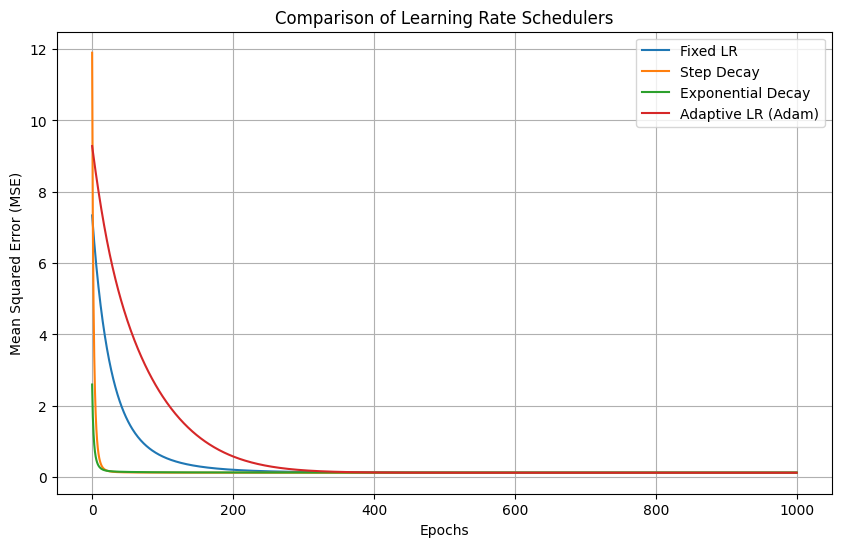

In [13]:
plt.figure(figsize=(10,6))
for name, (_, cost_history) in results.items():
    plt.plot(cost_history, label=name)

plt.xlabel("Epochs")
plt.ylabel("Mean Squared Error (MSE)")
plt.title("Comparison of Learning Rate Schedulers")
plt.legend()
plt.grid()
plt.show()